<a href="https://colab.research.google.com/github/Leonidas731/inovacao-tec-2ds/blob/main/c_pia_de_2ds_experimento_visao_computacional_com_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENTO: algoritmo para classificação de imagens com Python

SALVE UMA CÓPIA DESTE NOTEBOOK NO SEU DRIVE ANTES DE EXECUTÁ-LO!

Carregando modelo e preparando ambiente...
Baixando e processando a imagem...
Realizando previsão...
Exibindo resultados...


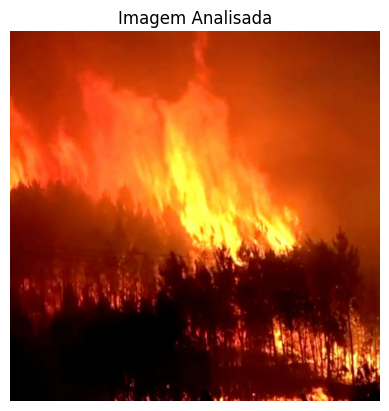

Classificação: volcano
Percentual de acerto: 95.54%

Resumo da execução: O algoritmo realizou a classificação da imagem fornecida usando um modelo de Rede Neural Convolucional pré-treinado (ResNet18) da biblioteca PyTorch. Primeiramente, a imagem foi baixada da URL e pré-processada (redimensionada, cortada e normalizada) para se adequar ao formato de entrada do modelo. Em seguida, o modelo previu a classe mais provável da imagem com base nas 1000 categorias do ImageNet. Finalmente, o resultado (nome da classe e confiança) foi exibido, com a classe traduzida para o português quando disponível.


In [ ]:
# Importa as bibliotecas necessárias
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

# Desabilita notação científica para maior clareza
np.set_printoptions(suppress=True)

print("Carregando modelo e preparando ambiente...")

# 1. Carregar um modelo pré-treinado (ResNet18, por exemplo)
# Usamos o ResNet18 pré-treinado no ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval() # Coloca o modelo em modo de avaliação

# 2. Definir as transformações de pré-processamento para a imagem
transform = transforms.Compose([
    transforms.Resize(256),            # Redimensiona para 256 pixels
    transforms.CenterCrop(224),        # Corta o centro para 224x224 pixels
    transforms.ToTensor(),             # Converte a imagem para tensor PyTorch
    transforms.Normalize(              # Normaliza a imagem com médias e desvios padrão do ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3. Carregar os nomes das classes do ImageNet
# Baixa os rótulos do ImageNet (1000 classes)
LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
response = requests.get(LABELS_URL)
class_names_en = response.json()

# Mapeamento para nomes de classes em português (apenas alguns exemplos relevantes)
class_names_pt = {
    "pine tree": "Pinheiro",
    "tree": "Árvore",
    "forest": "Floresta",
    "conifer": "Conífera",
    "cypress": "Cipreste",
    "lumber, timber": "Madeira",
    "leaf": "Folha",
    "branch": "Galho",
    "wood": "Madeira",
    "plain, pampas, veld, steppe, savanna": "Planície, savana"
    # Adicione mais traduções conforme necessário
}

# URL da imagem para teste
image_url = "https://admin.cnnbrasil.com.br/wp-content/uploads/sites/12/2023/05/2023-05-19T145908Z_1_LYNXMPEJ4I0MP_RTROPTP_4_ESPANHA-INCENDIO.jpg?w=1200&h=1200&crop=1"

print("Baixando e processando a imagem...")
# 4. Baixar e abrir a imagem
try:
    response = requests.get(image_url)
    response.raise_for_status() # Levanta um erro para códigos de status HTTP ruins
    image = Image.open(BytesIO(response.content)).convert("RGB")
except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar a imagem: {e}")
    exit()
except Exception as e:
    print(f"Erro ao abrir a imagem: {e}")
    exit()

# 5. Pré-processar a imagem
input_tensor = transform(image)
input_batch = input_tensor.unsqueeze(0) # Adiciona uma dimensão de batch

print("Realizando previsão...")
# 6. Realizar a previsão
with torch.no_grad():
    output = model(input_batch)

# Aplica Softmax para obter probabilidades
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Obtém a classe com a maior probabilidade
confidence, predicted_idx = torch.max(probabilities, 0)

# Obtém o nome da classe em inglês
predicted_class_en = class_names_en[predicted_idx.item()]

# Tenta traduzir o nome da classe para português
predicted_class_pt = class_names_pt.get(predicted_class_en.lower(), predicted_class_en)

# Converte a confiança para percentual
confidence_percent = confidence.item() * 100

print("Exibindo resultados...")
# 7. Exibir a imagem analisada
plt.imshow(image)
plt.axis('off') # Remove os eixos
plt.title("Imagem Analisada")
plt.show()

# 8. Exibir a classificação com nome em português e percentual de acerto
print(f"Classificação: {predicted_class_pt}")
print(f"Percentual de acerto: {confidence_percent:.2f}%")

# 9. Resumo em PT-BR do que o algoritmo executou
summary = (
    "O algoritmo realizou a classificação da imagem fornecida usando um modelo de Rede Neural Convolucional "
    "pré-treinado (ResNet18) da biblioteca PyTorch. Primeiramente, a imagem foi baixada da URL e "
    "pré-processada (redimensionada, cortada e normalizada) para se adequar ao formato de entrada do modelo. "
    "Em seguida, o modelo previu a classe mais provável da imagem com base nas 1000 categorias do ImageNet. "
    "Finalmente, o resultado (nome da classe e confiança) foi exibido, com a classe traduzida para o português quando disponível."
)
print(f"\nResumo da execução: {summary}")


<b>Como o modelo treinado ``keras_Model.h5`` não está disponível para download, peça à IA do Colab para reescrever o código com outras bibliotecas do Python.</b>  

</br>
PROMPT SUGERIDO: <i>Reescreva o código para executar mesma tarefa de classificação de imagens com visão computacional, usando outras bibliotecas do Python, com saídas e textos na tela escritos em português brasileiro, utilize o link desta imagem para teste "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg". Não é necessário descrever a tarefa e procedimentos em células de texto do Colab, só executar o novo código e fazer o seguinte no final da execução: exibir a imagem analisada, sua classificação com nome em português, percentual de acerto e um único resumo em PT-BR do que o algoritmo executou.</i>

In [ ]:
# Clicar no lápis para ativar a IA, copiar o PROMPT e enviar.
# Aguarde a resposta completa, aceite e execute o novo código.

🎉 Parabéns por concluir a tarefa!   
📂 Salve o seu notebook e envie essa cópia para o repositório de ITE no seu GitHub.   
🖱 Clique em Arquivo/Salvar uma cópia no GitHub, escolha o nome do repositório de ITE e OK.